Kích thước tập Train: (8984, 12)
Kích thước tập Test:  (2246, 12)

--- Đang huấn luyện mô hình: Decision Tree ---
Độ chính xác (Accuracy): 0.8976
Báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.55      0.57      0.56       251
           1       0.94      0.94      0.94      1988
           2       0.50      0.29      0.36         7

    accuracy                           0.90      2246
   macro avg       0.66      0.60      0.62      2246
weighted avg       0.90      0.90      0.90      2246



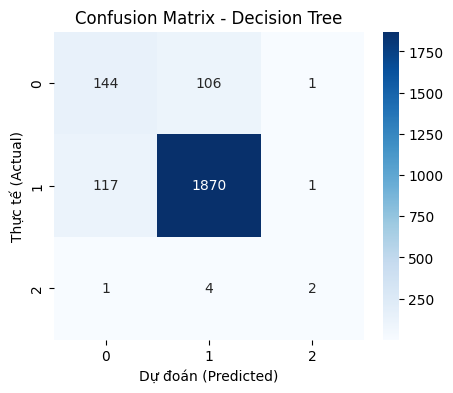


--- Đang huấn luyện mô hình: Random Forest ---
Độ chính xác (Accuracy): 0.9225
Báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.70      0.55      0.61       251
           1       0.94      0.97      0.96      1988
           2       0.67      0.29      0.40         7

    accuracy                           0.92      2246
   macro avg       0.77      0.60      0.66      2246
weighted avg       0.92      0.92      0.92      2246



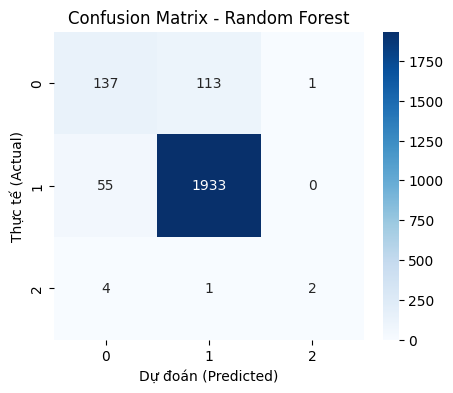


--- Đang huấn luyện mô hình: XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:24:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Độ chính xác (Accuracy): 0.9261
Báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.71      0.58      0.64       251
           1       0.95      0.97      0.96      1988
           2       0.67      0.29      0.40         7

    accuracy                           0.93      2246
   macro avg       0.78      0.61      0.67      2246
weighted avg       0.92      0.93      0.92      2246



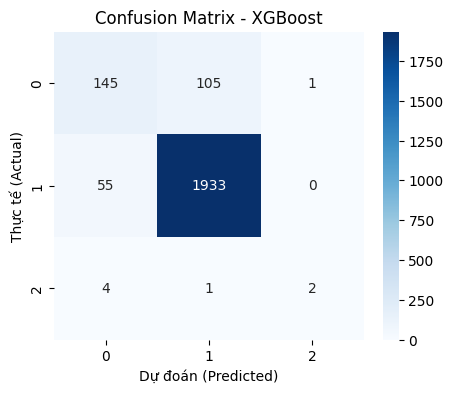


TỔNG HỢP ĐỘ CHÍNH XÁC CỦA CÁC MÔ HÌNH:
- Decision Tree: 89.76%
- Random Forest: 92.25%
- XGBoost: 92.61%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('cleaned_kmeans_clustered_full.csv')

cols_to_drop = ['Diện tích', 'Khoảng giá', 'Giá m2']
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]

X = df.drop(columns=existing_cols_to_drop + ['Cluster'])
y = df['Cluster']

categorical_cols = X.select_dtypes(include=['object']).columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].fillna('Unknown').astype(str))
    label_encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test:  {X_test.shape}\n")

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

results = {}

for name, model in models.items():
    print(f"--- Đang huấn luyện mô hình: {name} ---")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"Độ chính xác (Accuracy): {acc:.4f}")
    print("Báo cáo phân loại:")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Dự đoán (Predicted)')
    plt.ylabel('Thực tế (Actual)')
    plt.show()
    print("="*60 + "\n")

print("TỔNG HỢP ĐỘ CHÍNH XÁC CỦA CÁC MÔ HÌNH:")
for name, acc in results.items():
    print(f"- {name}: {acc*100:.2f}%")

# Lưu model

In [5]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('cleaned_kmeans_clustered_full.csv')

cols_to_drop = ['Diện tích', 'Khoảng giá', 'Giá m2']
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]

X_raw = df.drop(columns=existing_cols_to_drop + ['Cluster'])
y_raw = df['Cluster']

categorical_cols = X_raw.select_dtypes(include=['object']).columns.tolist()
print(f"Các cột sẽ được Pipeline tự động mã hóa: {categorical_cols}")

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ],
    remainder='passthrough'
)

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

print("Đang huấn luyện Pipeline XGBoost...")
xgb_pipeline.fit(X_train, y_train)

y_pred = xgb_pipeline.predict(X_test)
print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_pred):.4f}")

joblib.dump(xgb_pipeline, 'xgb_pipeline.pkl')
joblib.dump(X_raw.columns.tolist(), 'feature_columns.pkl')
print("\nĐã lưu Pipeline thành công!")

Các cột sẽ được Pipeline tự động mã hóa: ['Pháp lý', 'Nội thất', 'Phường', 'Quận']
Đang huấn luyện Pipeline XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:54:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Độ chính xác (Accuracy): 0.9252

Đã lưu Pipeline thành công!
